In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

In [13]:
wsl = pd.read_csv("data/wsl_4192026.csv")
hydra = pd.read_csv("data/hydra0_4192026.csv")
ubuntu = pd.read_csv("data/ubuntu_4192026.csv")

wsl["time"] = wsl["time"] * 1_000_000
hydra["time"] = hydra["time"] * 1_000_000
ubuntu["time"] = ubuntu["time"] * 1_000_000

print(wsl.head())
print(hydra.head())
print(ubuntu.head())

   n      time
0  3  644.4229
1  4  242.3316
2  5  227.4193
3  6  208.1611
4  7  243.7394
   n       time
0  3  90.824813
1  4  79.736114
2  5  77.704899
3  6  78.381412
4  7  77.845901
   n      time
0  3  428.7013
1  4  153.0742
2  5  145.2378
3  6  129.1949
4  7  125.0532


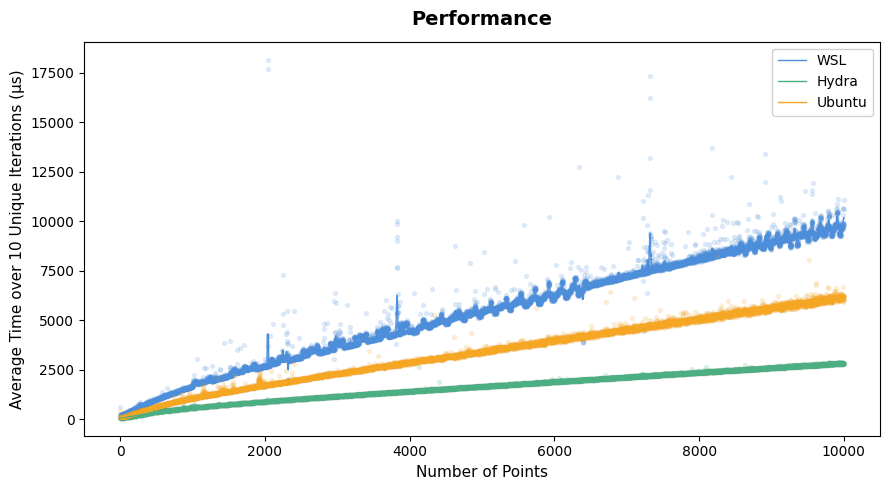

In [19]:
fig, ax = plt.subplots(figsize=(9, 5))

datasets = {
    "WSL": wsl,
    "Hydra": hydra,
    "Ubuntu": ubuntu,
}

colors = {
    "WSL": "#4C8EDA",
    "Hydra": "#4CAF82",
    "Ubuntu": "#F5A623",
}

for label, df in datasets.items():
    color = colors[label]
    sorted_df = df.sort_values("n")
    
    # Rolling mean to smooth the line
    smoothed = sorted_df.set_index("n")["time"].rolling(window=20, center=True, min_periods=1).mean()
    
    # Faint scatter of raw points
    ax.scatter(sorted_df["n"], sorted_df["time"], color=color, alpha=0.15, s=8, zorder=2)
    
    # Bold mean line on top
    ax.plot(smoothed.index, smoothed.values, color=color, linewidth=1, label=label, zorder=3)

ax.set_title("Performance", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Number of Points", fontsize=11)
ax.set_ylabel("Average Time over 10 Unique Iterations (μs)", fontsize=11)
ax.legend(framealpha=0.9, fontsize=10)

plt.tight_layout()
plt.show()